In [18]:
#START - GETTING STARTED WITH EXPLORATION

# --- Core imports ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Always show plots inline
%matplotlib inline

# --- Path sanity check ---
print("Notebook running from:", Path.cwd())

# Define project paths
ROOT = Path("..").resolve()   # one level up from 'notebooks' → 'BBO'
DATA = ROOT / "data"

print("ROOT:", ROOT)
print("DATA:", DATA)

# List subfolders/files inside data
print("Contents of DATA:")
for p in sorted(DATA.iterdir()):
    print("   ", p.name)

Notebook running from: C:\Users\elena\Documents\BBO\notebooks
ROOT: C:\Users\elena\Documents\BBO
DATA: C:\Users\elena\Documents\BBO\data
Contents of DATA:
    F1
    F2
    F3
    F4
    F5
    F6
    F7
    F8
    function_summary.csv


In [19]:
#DATA LOADING SECTION
# --- Select which function to inspect ---
FN = "F2"   # change to F2..F8 as needed
print(f"Loading data for {FN}")

# --- Read function description ---
summary_path = DATA / "function_summary.csv"
func_info = pd.read_csv(summary_path)

if "Function" in func_info.columns and "Description" in func_info.columns:
    desc_row = func_info.loc[func_info["Function"] == FN, "Description"]
    if not desc_row.empty:
        print(f"\n{FN} description:\n{desc_row.values[0]}")
    else:
        print(f"No description found for {FN} in function_summary.csv.")
else:
    print("⚠️ function_summary.csv missing expected columns.")

# --- Load inputs/outputs ---
X_path = DATA / FN / "initial_inputs.npy"
y_path = DATA / FN / "initial_outputs.npy"

X = np.load(X_path)
y = np.load(y_path)

# --- Build DataFrame for exploration ---
cols = [f"x{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=cols)
df["y"] = y

# --- Show quick look ---
display(df.head())
display(df.describe())

# --- Summary dictionary ---
summary = {
    "rows": len(df),
    "dims": X.shape[1],
    "bounds": {c: (float(df[c].min()), float(df[c].max())) for c in cols},
    "y_min": float(df["y"].min()),
    "y_max": float(df["y"].max()),
}
print("\nSummary of loaded data:")
summary


Loading data for F2

F2 description:
Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965


,x1,x2,y
count,11.000000,11.000000,11.000000
mean,0.555466,0.443573,0.255728
std,0.231935,0.337557,0.240195
min,0.142699,0.000000,-0.065624
25%,0.389958,0.168918,0.030927
50%,0.577713,0.349005,0.244619
75%,0.713818,0.741547,0.463427
max,0.877791,0.926564,0.611205



Summary of loaded data:


{'rows': 11,
 'dims': 2,
 'bounds': {'x1': (0.14269907423594608, 0.8777909889953304),
  'x2': (0.0, 0.9265641975455574)},
 'y_min': -0.06562362443733738,
 'y_max': 0.6112052157614438}

In [20]:
# --- save summary info + notes + timestamp to spreadsheet ---
sdf = pd.read_csv(DATA / "function_summary.csv")
note = f"Exploration: {summary['dims']}D, {summary['rows']} pts. y∈[{summary['y_min']:.6g},{summary['y_max']:.3g}]"
now  = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

sdf.loc[sdf["Function"] == FN,
        ["Rows","Dims","Bounds","y_min","y_max","Best_y_so_far","Notes","Last_updated"]] = [
    summary["rows"], summary["dims"], str(summary["bounds"]),
    summary["y_min"], summary["y_max"], summary["y_max"], note, now
]

sdf.to_csv(DATA / "function_summary.csv", index=False)


F2 has 2 input dimensions


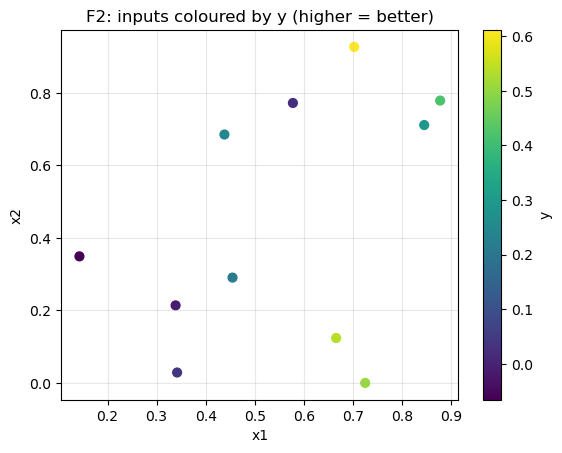

In [21]:
#INITIAL PLOTS TO VISUALISE THE DATA

# --- Quick visual exploration of inputs and outputs ---
import seaborn as sns

xs = [c for c in df.columns if c.startswith("x")]
d = len(xs)

print(f"{FN} has {d} input dimensions")

sc = plt.scatter(df[xs[0]], df[xs[1]], c=df["y"], cmap="viridis", s=40)
plt.xlabel(xs[0]); plt.ylabel(xs[1])
plt.title(f"{FN}: inputs coloured by y (higher = better)")
plt.colorbar(sc, label="y")
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# === F2: GP + Expected Improvement (MINIMIZATION) — local Jupyter, no SciPy ===
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

# ---------------- Vectorized PDF / CDF (no SciPy, no math.erf) ----------------
# PDF of standard normal
def std_norm_pdf(z):
    z = np.asarray(z, dtype=np.float64)
    return np.exp(-0.5 * z * z) / np.sqrt(2.0 * np.pi)

# CDF of standard normal (Abramowitz & Stegun 7.1.26 approximation; vectorized)
def std_norm_cdf(z):
    z = np.asarray(z, dtype=np.float64)
    # constants
    p = 0.2316419
    a1, a2, a3, a4, a5 = 0.319381530, -0.356563782, 1.781477937, -1.821255978, 1.330274429
    x = np.clip(z, -8.0, 8.0)           # keep things well-behaved in tails
    t = 1.0 / (1.0 + p * np.abs(x))
    poly = (((((a5 * t + a4) * t) + a3) * t + a2) * t + a1) * t
    cdf_pos = 1.0 - std_norm_pdf(x) * poly
    # use symmetry for negative x
    return np.where(x >= 0, cdf_pos, 1.0 - cdf_pos)

def expected_improvement_min(mu, sd, y_best, xi=0.01):
    sd = np.asarray(sd, dtype=np.float64).reshape(-1)
    mu = np.asarray(mu, dtype=np.float64).reshape(-1)
    imp = (y_best - mu - xi)
    z = np.divide(imp, sd, out=np.zeros_like(imp), where=sd > 1e-12)
    return imp * std_norm_cdf(z) + sd * std_norm_pdf(z)

# ---------------- Load your data (use local files if X,y not already defined) ----------------
try:
    X; y
except NameError:
    X = np.load("initial_inputs.npy")    # <- change path if needed
    y = np.load("initial_outputs.npy")   # <- change path if needed

assert X.ndim == 2 and X.shape[1] == 2, "F2 expects 2D inputs in [0,1]."
assert y.ndim == 1 and y.shape[0] == X.shape[0], "y must be shape (n,) and match X."

# ---------------- Fit a sturdy GP (minimization) ----------------
kernel = (C(1.0, (1e-6, 1e6)) *
          Matern(length_scale=[0.2, 0.2], length_scale_bounds=(1e-3, 1e3), nu=2.5)
          + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-3)))

gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0,
                              normalize_y=True, n_restarts_optimizer=5,
                              random_state=0)
gp.fit(X, y)

# ---------------- Candidates strictly on portal bounds [0,1]^2 ----------------
g = np.linspace(0.0, 1.0, 401)  # 160k candidates; fast for 2D
G = np.array(np.meshgrid(g, g)).reshape(2, -1).T

# ---------------- EI (minimization) ----------------
mu, sd = gp.predict(G, return_std=True)
y_best = float(np.min(y))
EI = expected_improvement_min(mu, sd, y_best, xi=0.01)

pick_idx = int(np.argmax(EI))
x_next = G[pick_idx]

# ---------------- Distance to nearest observed point (pure NumPy) ----------------
diff = X - x_next
min_dist = float(np.sqrt((diff * diff).sum(axis=1)).min())

# ---------------- OUTPUT ----------------
print("\n" + "="*70)
print("F2 — RECOMMENDED NEXT POINT")
print("="*70)
print(f"Best y so far: {y_best:.6f}")
print(f"Chosen by EI (xi=0.01): predicted mean={mu[pick_idx]:.6f}, "
      f"std={sd[pick_idx]:.6f}, EI={EI[pick_idx]:.6e}")
print(f"Min distance from existing points: {min_dist:.3f}")

x_next_df = pd.DataFrame([x_next], columns=["x1", "x2"]).round(6)
display(x_next_df.style.set_caption("🚀 Submit this point"))

# ---------------- Optional: persist a one-line log for weekly tracking ----------------
import os
log_path = "F2_picks_log.csv"
(pd.DataFrame([{
    "fn": "F2",
    "x1": float(x_next[0]),
    "x2": float(x_next[1]),
    "pred_mu": float(mu[pick_idx]),
    "pred_sd": float(sd[pick_idx]),
    "EI": float(EI[pick_idx]),
    "y_best": y_best
}]).to_csv(log_path, mode="a", header=not os.path.exists(log_path), index=False))

print("="*70)
print("Copy these values into the portal for this week's query.")
print("="*70)



F2 — RECOMMENDED NEXT POINT
Best y so far: -0.065624
Chosen by EI (xi=0.01): predicted mean=-0.098681, std=0.114492, EI=5.812734e-02
Min distance from existing points: 0.339


,x1,x2
0,0.312500,1.000000


Copy these values into the portal for this week's query.
